# SPBD 2526 Project 1

## Presentation Report

In [2]:
#@title Download 1% sample
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

# 1. Core Analytics Execution: High-Value Trip Patterns


## 1.1 High-Value Geographic Hotspots

### Data Cleaning

In [3]:
from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *

spark = SparkSession.builder.master('local[*]') \
            .appName('taxis').getOrCreate()

schema = StructType([
    StructField("medallion", StringType(), True),
    StructField("hack_license", StringType(), True),
    StructField("pickup_datetime", TimestampType(), True),
    StructField("dropoff_datetime", TimestampType(), True),
    StructField("trip_time_in_secs", IntegerType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("payment_type", StringType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("surcharge", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("total_amount", DoubleType(), True)
])

data_typed3 = spark.read.csv(
    'taxi_rides_1pc.csv.gz',
    sep=',',
    header=True,
    schema=schema,
    timestampFormat='yyyy-MM-dd HH:mm:ss'
)

In [4]:
# Approximate boundaries for 300x300 NYC grid area
MIN_LON = -74.05 ###################################################To discuss: In the instructions -74.916578 also not using the In Bounds check and latlon_to_grid definition
MAX_LON = -73.75
MIN_LAT = 40.6 ###########################################################41.47718278
MAX_LAT = 40.9

LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

initial_count3 = data_typed3.count()

print(initial_count3)

data_filtered3 = data_typed3.filter(
    (col("pickup_longitude").between(MIN_LON, MAX_LON)) &
    (col("pickup_latitude").between(MIN_LAT, MAX_LAT)) &
    (col("dropoff_longitude").between(MIN_LON, MAX_LON)) &
    (col("dropoff_latitude").between(MIN_LAT, MAX_LAT)) &
    (col("trip_time_in_secs") > 0) &
    (col("total_amount") > 0)
)

print(data_filtered3.count())

1735010
1691438


Create columns: avg-speed, fare-per-mile, tip-pct

Filter for:
"avg_speed_mph" <= 155 /
"tip_amount" <= 50 /
"tip_pct" <= 3 /
1 <= "tip_amount" <= 20

To get fare per mile, we computed:
fare_per_mile = fare_amount / trip_distance

We did a calculation on example trips, based on numbers from NYC Taxi & Limousine Comission, 2025, and created two different scenarios:


**A: Expensive but feasible Manhattan trip**
Example: 0.2 mile trip
3.00 (initial charge) + 0.70x1 (Distance charge) + 0.5 (MTA State surcharge) + 1 (Improvement surcharge) + 2.5 (Yellow taxi) =  $7.70 (7.70 for o.2 miles, which means 1 mile = **38.5** dollars per mile)

**B: Unlikely case with Rush hour, night, congestion, and tolls**
3.00 (initial charge) + 0.70x1 (Distance charge) + 0.5 (MTA State surcharge) + 1 (Improvement surcharge) + 2.5 (Yellow taxi) + 0.75 (Congestion Pricing Toll) + 2.50 (Rush-hour surcharge) + 1 (Overnight) + 0.75 (Congestion Pricing Toll ) = 11.95 (i mile = **59.75** dollars/mile)

However, prices have most likely increased since 2013.


In [5]:
from pyspark.sql.functions import col

# Create avarage speed column
data_filtered3 = data_filtered3.withColumn(
    "avg_speed_mph",
    col("trip_distance") / (col("trip_time_in_secs") / 3600.0)
)

# Create fare_per_mile column
data_filtered3 = data_filtered3.withColumn(
    "fare_per_mile",
    col("fare_amount") / col("trip_distance")
)

data_filtered3 = data_filtered3.withColumn(
    "tip_pct",
    when(col("fare_amount") > 0, col("tip_amount") / col("fare_amount"))
    .otherwise(lit(0.0))
)

# print counts
fast_trips_count = data_filtered3.filter(col("avg_speed_mph") > 155).count()
print("Number of trips over 155 mph:", fast_trips_count)

high_fpm_count = data_filtered3.filter(col("fare_per_mile") >= 50).count()
print("Trips with fare_per_mile > 50 USD:", high_fpm_count)
low_fpm_count  = data_filtered3.filter(col("fare_per_mile") < 1).count()
print("Trips with fare_per_mile < 1 USD:",  low_fpm_count)

tips_300_count = data_filtered3.filter(col("tip_pct") >= 3).count()
print("Trips with tip >= 300% of fare:", tips_300_count)

tips_50USD = data_filtered3.filter(col("tip_amount") > 50).count()
print("Tip amount > 50 USD:", tips_50USD)


data_filtered3 = data_filtered3.filter(
    (col("avg_speed_mph") <= 155) &
    (col("tip_amount") <= 50) &
    (col("tip_pct") <= 3) &
    (
        col("fare_per_mile").isNull() |
        (
            (col("fare_per_mile") >= 1) &
            (col("fare_per_mile") <= 50)
        )
    )
)
print("Remaining rows after cleaning:", data_filtered3.count())

Number of trips over 155 mph: 793
Trips with fare_per_mile > 20 USD: 5428
Trips with fare_per_mile < 1 USD: 1204
Trips with tip >= 300% of fare: 150
Tip amount > 50 USD: 59
Remaining rows after cleaning: 1684811


Add the pickup and dropoff zones

In [6]:
# Calculate Grid X/Y for Dropoff
data_with_grid = data_filtered3.withColumn(
    "dropoff_grid_x",
    floor((col("dropoff_longitude") - MIN_LON) / LON_DELTA).cast(IntegerType())
).withColumn(
    "dropoff_grid_y",
    floor((col("dropoff_latitude") - MIN_LAT) / LAT_DELTA).cast(IntegerType())
)

# Calculate Grid X/Y for Pickup (Needed for Part B)
data_with_grid = data_with_grid.withColumn(
    "pickup_grid_x",
    floor((col("pickup_longitude") - MIN_LON) / LON_DELTA).cast(IntegerType())
).withColumn(
    "pickup_grid_y",
    floor((col("pickup_latitude") - MIN_LAT) / LAT_DELTA).cast(IntegerType())
)

### PART A: HIGH-FARE DESTINATIONS

**What are the top 10 drop-off grid cells that yield the highest average total amount**

In [7]:
# 1. Group by Dropoff Zone and Calculate Stats
grid_analysis = data_with_grid.groupBy("dropoff_grid_x", "dropoff_grid_y") \
    .agg(
        avg("fare_per_mile").alias("avg_fare_per_mile"),
        count("*").alias("trip_count"),
        (avg("trip_time_in_secs") / 60).alias("avg_time_mins")
    )

# 2. Filter for Statistical Significance
grid_analysis_filtered = grid_analysis.filter(col("trip_count") >= 20)

# 3. Get Top 10 Most Expensive Zones per Mile
top_10_destinations = grid_analysis_filtered \
    .orderBy(col("avg_fare_per_mile").desc()) \
    .limit(10)

print("--- Top 10 High-Value Drop-off Zones (Fare Per Mile) ---")
top_10_destinations.show()

--- Top 10 High-Value Drop-off Zones (Fare Per Mile) ---
+--------------+--------------+------------------+----------+------------------+
|dropoff_grid_x|dropoff_grid_y| avg_fare_per_mile|trip_count|     avg_time_mins|
+--------------+--------------+------------------+----------+------------------+
|             3|            34|12.761031328996195|        39|13.197435897435897|
|             4|            34| 12.55350937756418|        30|14.647222222222222|
|             1|            25|12.251592645882551|        34|19.726960784313725|
|             2|            33|12.105386326899264|        29|12.798275862068966|
|             4|            35| 11.06243614268972|        20|12.544166666666666|
|             1|            30|11.015279090841815|        37|17.238288288288288|
|             3|            30|10.815177955405655|        60|16.766666666666666|
|             2|            30| 10.72803907470813|        59|17.257909604519774|
|             3|            33|10.591859063695571|  

Upload data to kepler.gl

In [ ]:
# --- Export 1: The Grid Heatmap (Now showing Fare Per Mile) ---
kepler_grid_data = grid_analysis_filtered.withColumn(
    "center_longitude",
    lit(MIN_LON) + (col("dropoff_grid_x") * lit(LON_DELTA)) + (lit(LON_DELTA) / 2)
).withColumn(
    "center_latitude",
    lit(MIN_LAT) + (col("dropoff_grid_y") * lit(LAT_DELTA)) + (lit(LAT_DELTA) / 2)
)

kepler_grid_data.select(
    "center_longitude", "center_latitude",
    "avg_fare_per_mile", "trip_count", "avg_time_mins"
).coalesce(1).write.csv("kepler_grid_heatmap_fpm.csv", header=True, mode="overwrite")

We export also the the top 10 fare-per-mile

In [ ]:
# 1. Convert Grid IDs back to Lat/Lon Centers
kepler_top10 = top_10_destinations.withColumn(
    "center_longitude",
    lit(MIN_LON) + (col("dropoff_grid_x") * lit(LON_DELTA)) + (lit(LON_DELTA) / 2)
).withColumn(
    "center_latitude",
    lit(MIN_LAT) + (col("dropoff_grid_y") * lit(LAT_DELTA)) + (lit(LAT_DELTA) / 2)
)

# 2. Select columns for Kepler
export_top10 = kepler_top10.select(
    "center_longitude",
    "center_latitude",
    "avg_fare_per_mile",
    "trip_count",
    "avg_time_mins"
)

# 3. Export to CSV
export_top10.coalesce(1).write.csv(
    "kepler_top10_high_value_zones.csv",
    header=True,
    mode="overwrite"
)

print("Export complete! File: 'kepler_top10_high_value_zones.csv'")

Export complete! File: 'kepler_top10_high_value_zones.csv'


## PART B: ORIGIN ANALYSIS

**For those top drop-off cells (from 3.1.A), where do the high-fare trips most frequently originate?**

In [ ]:
# 1. Filter to keep ONLY trips going to the Top 10 destinations
trips_to_top_zones = data_with_grid.join(
    top_10_destinations,
    on=['dropoff_grid_x', 'dropoff_grid_y'],
    how='left_semi'
)

# 2. Group by Route (Dropoff -> Pickup) and Calculate Stats
route_stats = trips_to_top_zones.groupBy(
    "dropoff_grid_x", "dropoff_grid_y",
    "pickup_grid_x", "pickup_grid_y"
).agg(
    count("*").alias("route_frequency"),
    (avg("trip_time_in_secs") / 60).alias("avg_time_mins")
)

route_stats = route_stats.filter(col("avg_time_mins") >= 5.0)

# 3. Find the #1 Most Frequent Origin for each Destination
window_spec = Window.partitionBy("dropoff_grid_x", "dropoff_grid_y") \
    .orderBy(col("route_frequency").desc())

top_origins_with_time = route_stats.withColumn("rank", row_number().over(window_spec)) \
    .filter(col("rank") == 1) \
    .drop("rank") \
    .withColumnRenamed("pickup_grid_x", "top_origin_x") \
    .withColumnRenamed("pickup_grid_y", "top_origin_y")

final_origins = top_origins_with_time.join(
    top_10_destinations.select("dropoff_grid_x", "dropoff_grid_y", "avg_fare_per_mile"),
    on=['dropoff_grid_x', 'dropoff_grid_y']
)

print("--- Top High-Value Destinations (#1 Origin, Time > 1m, & Fare/Mile) ---")
final_origins.select(
    "dropoff_grid_x", "dropoff_grid_y",
    format_number("avg_fare_per_mile", 2).alias("avg_fare_per_mile"),
    "top_origin_x", "top_origin_y",
    "route_frequency",
    format_number("avg_time_mins", 1).alias("avg_mins")
).orderBy(col("avg_fare_per_mile").desc()).show()

--- Top High-Value Destinations (#1 Origin, Time > 1m, & Fare/Mile) ---
+--------------+--------------+-----------------+------------+------------+---------------+--------+
|dropoff_grid_x|dropoff_grid_y|avg_fare_per_mile|top_origin_x|top_origin_y|route_frequency|avg_mins|
+--------------+--------------+-----------------+------------+------------+---------------+--------+
|             3|            34|            12.76|          10|          34|              4|    15.5|
|             2|            33|            11.03|           9|          35|              4|     9.8|
|             1|            30|            10.62|          10|          35|              2|    17.5|
|             3|            33|            10.59|          10|          36|              4|    12.2|
|             3|            30|            10.58|          10|          35|              3|    16.4|
|             4|            33|            10.49|           4|          33|              6|     5.0|
|             3|   

Upload data to kepler

In [ ]:
# 1. Convert Grid IDs back to Lat/Lon
kepler_flow_data = final_origins.withColumn(
    "dest_lon", lit(MIN_LON) + (col("dropoff_grid_x") * LON_DELTA) + (LON_DELTA/2)
).withColumn(
    "dest_lat", lit(MIN_LAT) + (col("dropoff_grid_y") * LAT_DELTA) + (LAT_DELTA/2)
).withColumn(
    "origin_lon", lit(MIN_LON) + (col("top_origin_x") * LON_DELTA) + (LON_DELTA/2)
).withColumn(
    "origin_lat", lit(MIN_LAT) + (col("top_origin_y") * LAT_DELTA) + (LAT_DELTA/2)
)

# 2. Select columns (Added avg_fare_per_mile so you can color arcs by cost)
kepler_flow_data.select(
    "origin_lon", "origin_lat",
    "dest_lon", "dest_lat",
    "route_frequency",
    "avg_time_mins",
    "avg_fare_per_mile"  # <--- NEW: Visualization can now show cost
).coalesce(1).write.csv("kepler_flow_arcs_fpm.csv", header=True, mode="overwrite")

Now we visualize all the pickup points

In [8]:
# 1. Filter to keep ONLY trips going to the Top 10 destinations
trips_to_top_zones = data_with_grid.join(
    top_10_destinations,
    on=['dropoff_grid_x', 'dropoff_grid_y'],
    how='left_semi'
)

# 2. Group by Route (Dropoff -> Pickup) and Calculate Stats
all_routes_stats = trips_to_top_zones.groupBy(
    "dropoff_grid_x", "dropoff_grid_y",
    "pickup_grid_x", "pickup_grid_y"
).agg(
    count("*").alias("route_frequency"),
    (avg("trip_time_in_secs") / 60).alias("avg_time_mins")
)

# 3. Apply Filters
all_routes_stats = all_routes_stats.filter(
    (col("avg_time_mins") >= 5.0) &
    (
        (col("dropoff_grid_x") != col("pickup_grid_x")) |
        (col("dropoff_grid_y") != col("pickup_grid_y"))
    )
)

# 4. Join Price Info Back
final_all_routes = all_routes_stats.join(
    top_10_destinations.select("dropoff_grid_x", "dropoff_grid_y", "avg_fare_per_mile"),
    on=['dropoff_grid_x', 'dropoff_grid_y']
)

print(f"Total unique routes found: {final_all_routes.count()}")
final_all_routes.show(5)

Total unique routes found: 290
+--------------+--------------+-------------+-------------+---------------+------------------+------------------+
|dropoff_grid_x|dropoff_grid_y|pickup_grid_x|pickup_grid_y|route_frequency|     avg_time_mins| avg_fare_per_mile|
+--------------+--------------+-------------+-------------+---------------+------------------+------------------+
|             1|            25|            7|           25|              1|              27.0|12.251592645882551|
|             1|            25|           12|           33|              1|              26.0|12.251592645882551|
|             2|            27|           44|           10|              2|             40.05|10.500430893361186|
|             2|            30|           13|           36|              1|22.566666666666666| 10.72803907470813|
|             2|            27|           14|           45|              1|             46.45|10.500430893361186|
+--------------+--------------+-------------+------------

In [9]:
# 1. Convert Destination Grid IDs to Lat/Lon
kepler_arcs = final_all_routes.withColumn(
    "dest_lon", lit(MIN_LON) + (col("dropoff_grid_x") * LON_DELTA) + (LON_DELTA/2)
).withColumn(
    "dest_lat", lit(MIN_LAT) + (col("dropoff_grid_y") * LAT_DELTA) + (LAT_DELTA/2)
)

# 2. Convert Origin Grid IDs to Lat/Lon
kepler_arcs = kepler_arcs.withColumn(
    "origin_lon", lit(MIN_LON) + (col("pickup_grid_x") * LON_DELTA) + (LON_DELTA/2)
).withColumn(
    "origin_lat", lit(MIN_LAT) + (col("pickup_grid_y") * LAT_DELTA) + (LAT_DELTA/2)
)

# 3. Select columns for visualization
export_df = kepler_arcs.select(
    "origin_lon", "origin_lat",
    "dest_lon", "dest_lat",
    "route_frequency",
    "avg_time_mins",
    "avg_fare_per_mile"
)

# 4. Export
export_df.coalesce(1).write.csv(
    "kepler_all_arcs_top10.csv",
    header=True,
    mode="overwrite"
)

print("Export complete! File: 'kepler_all_arcs_top10.csv'")

Export complete! File: 'kepler_all_arcs_top10.csv'


## Outputs and conclusions

For a first approach to our data we will do some visualizations using a tool called kepler.gl [link](https://kepler.gl), which we import the csv directly from our notebook.

## Figure 1: Heatmap point chart of the dropoff avg-fare-per-mile.

We can clearly see that as we get close to the center of NY the price increases.

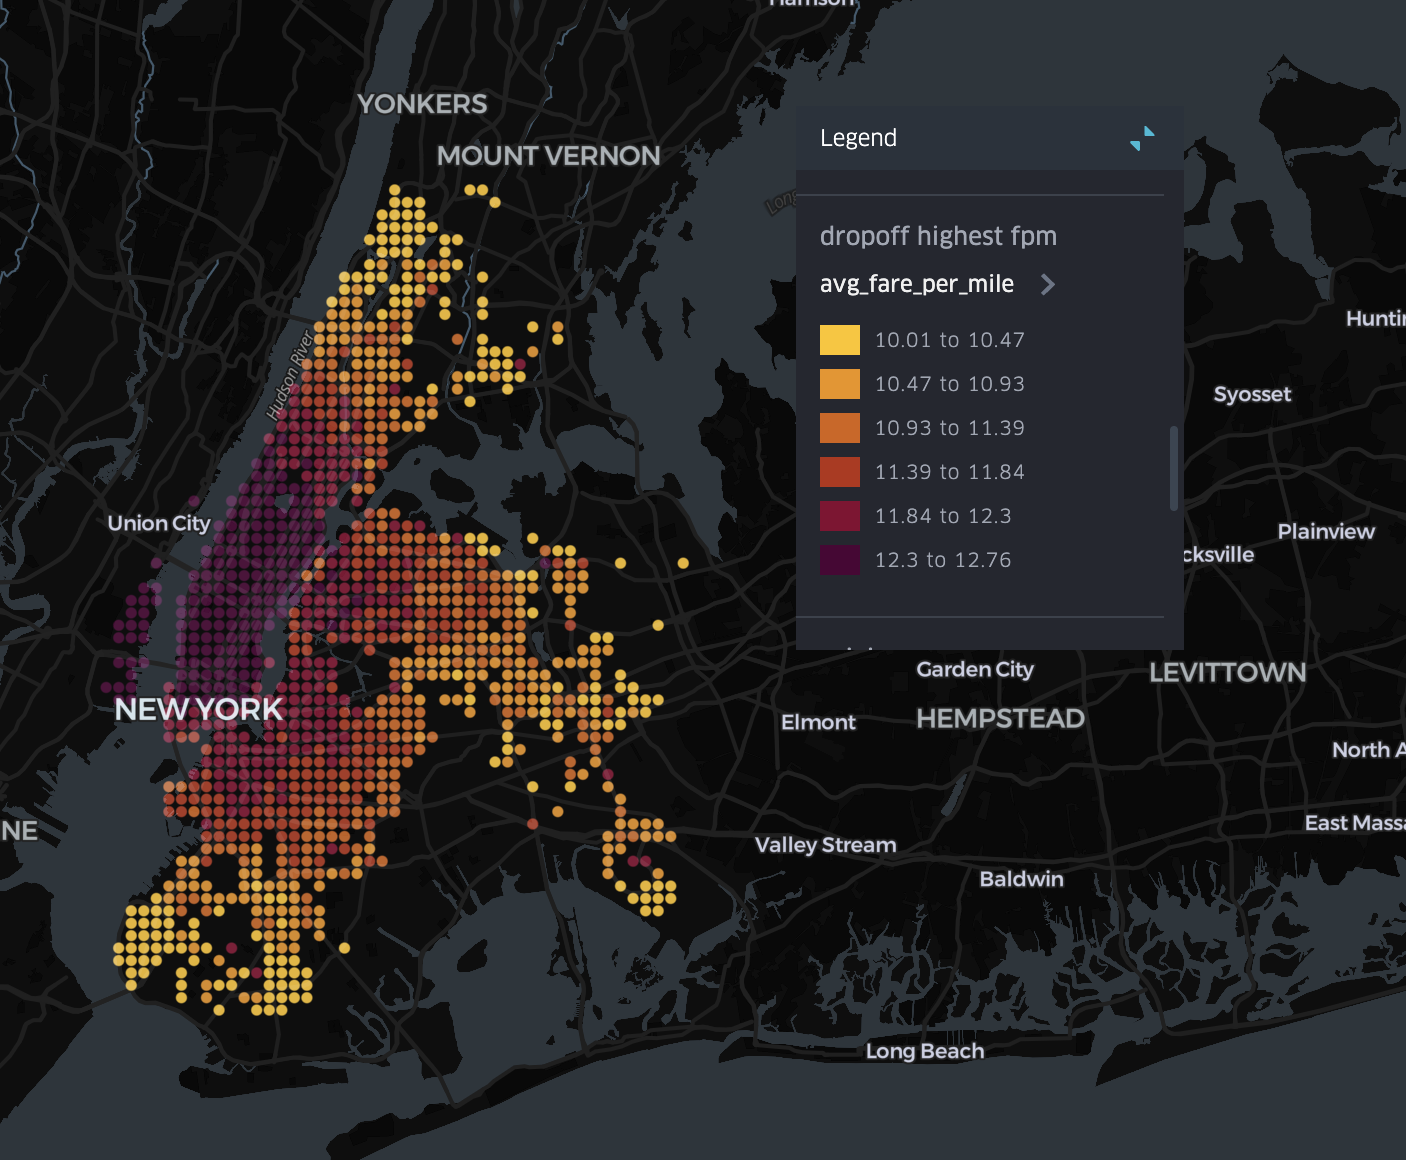

## Figure 2: Heatmap point chart of the dropoff avg-time

We clearly see that as the dropoff point gets further away from the center of the city, the trip time increases.

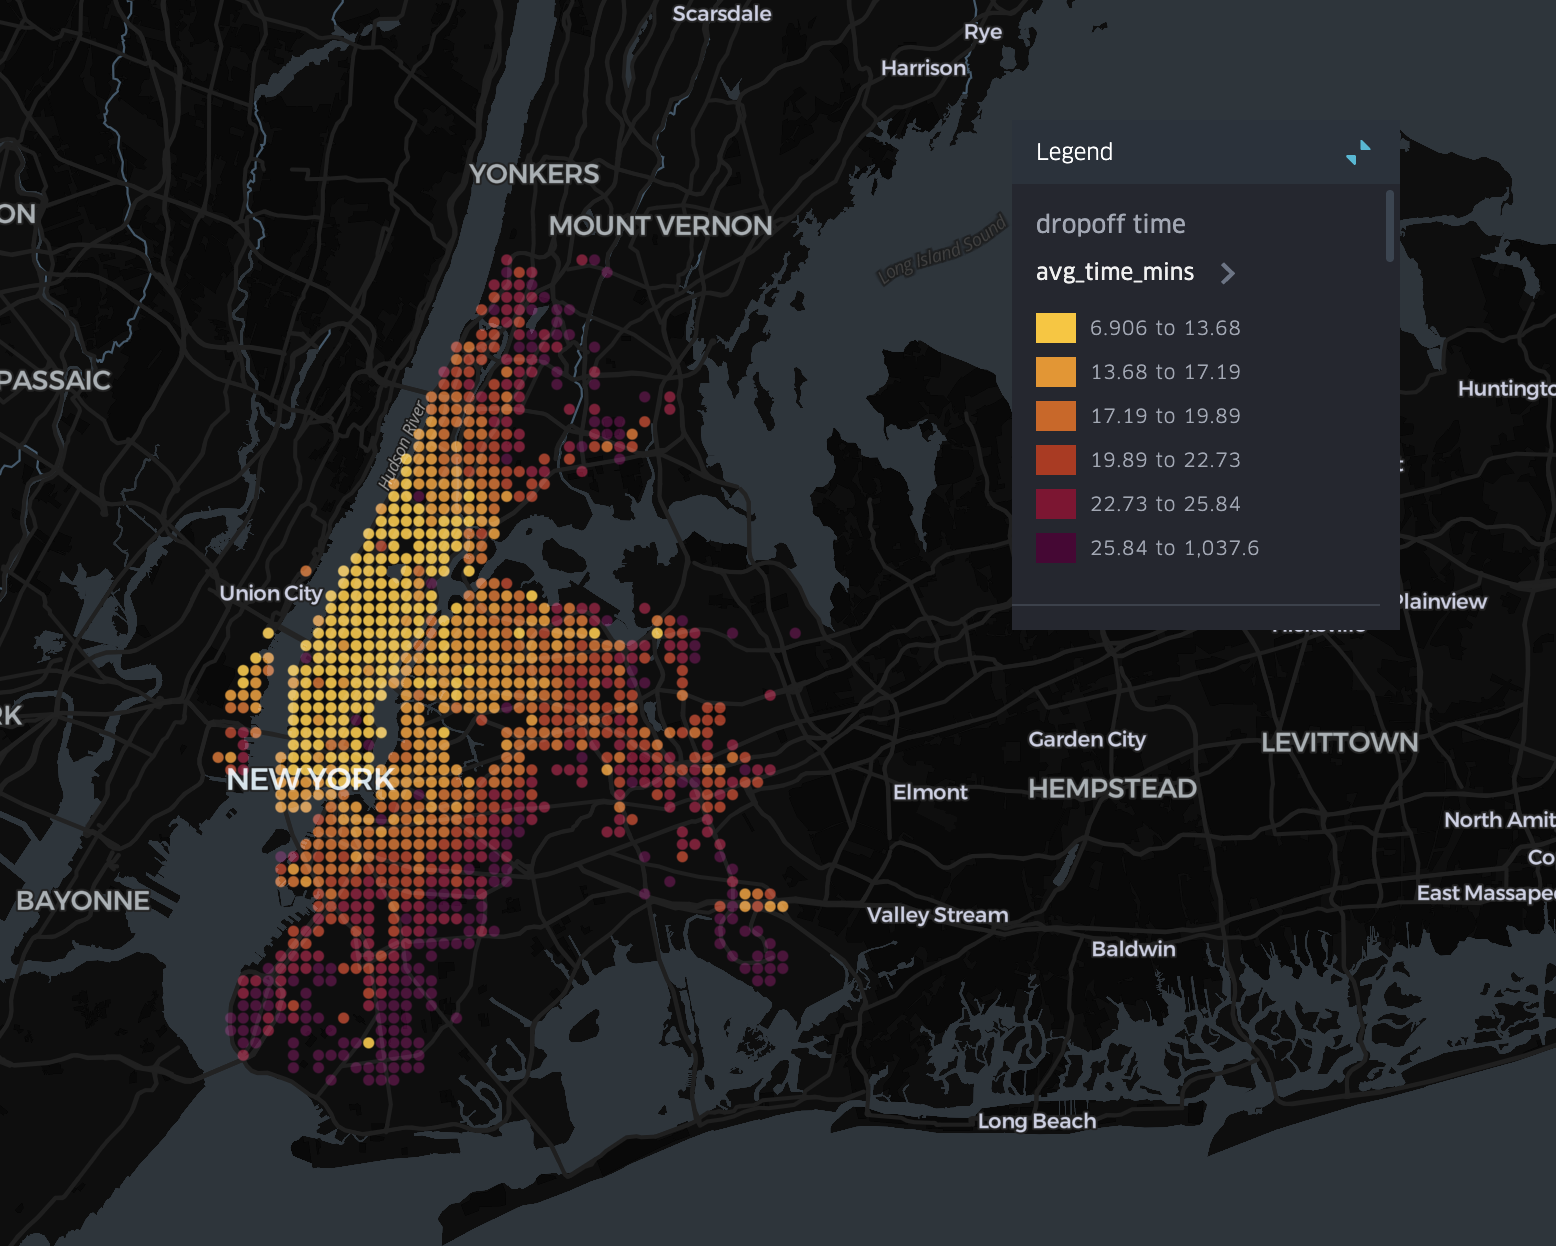

## Figure 3: Heatmap point chart of dropoff trip count

To back up the previous two charts we can see that in the center is where we found the highest density of trips dropoffs. Although it is still pretty busy in middle areas.

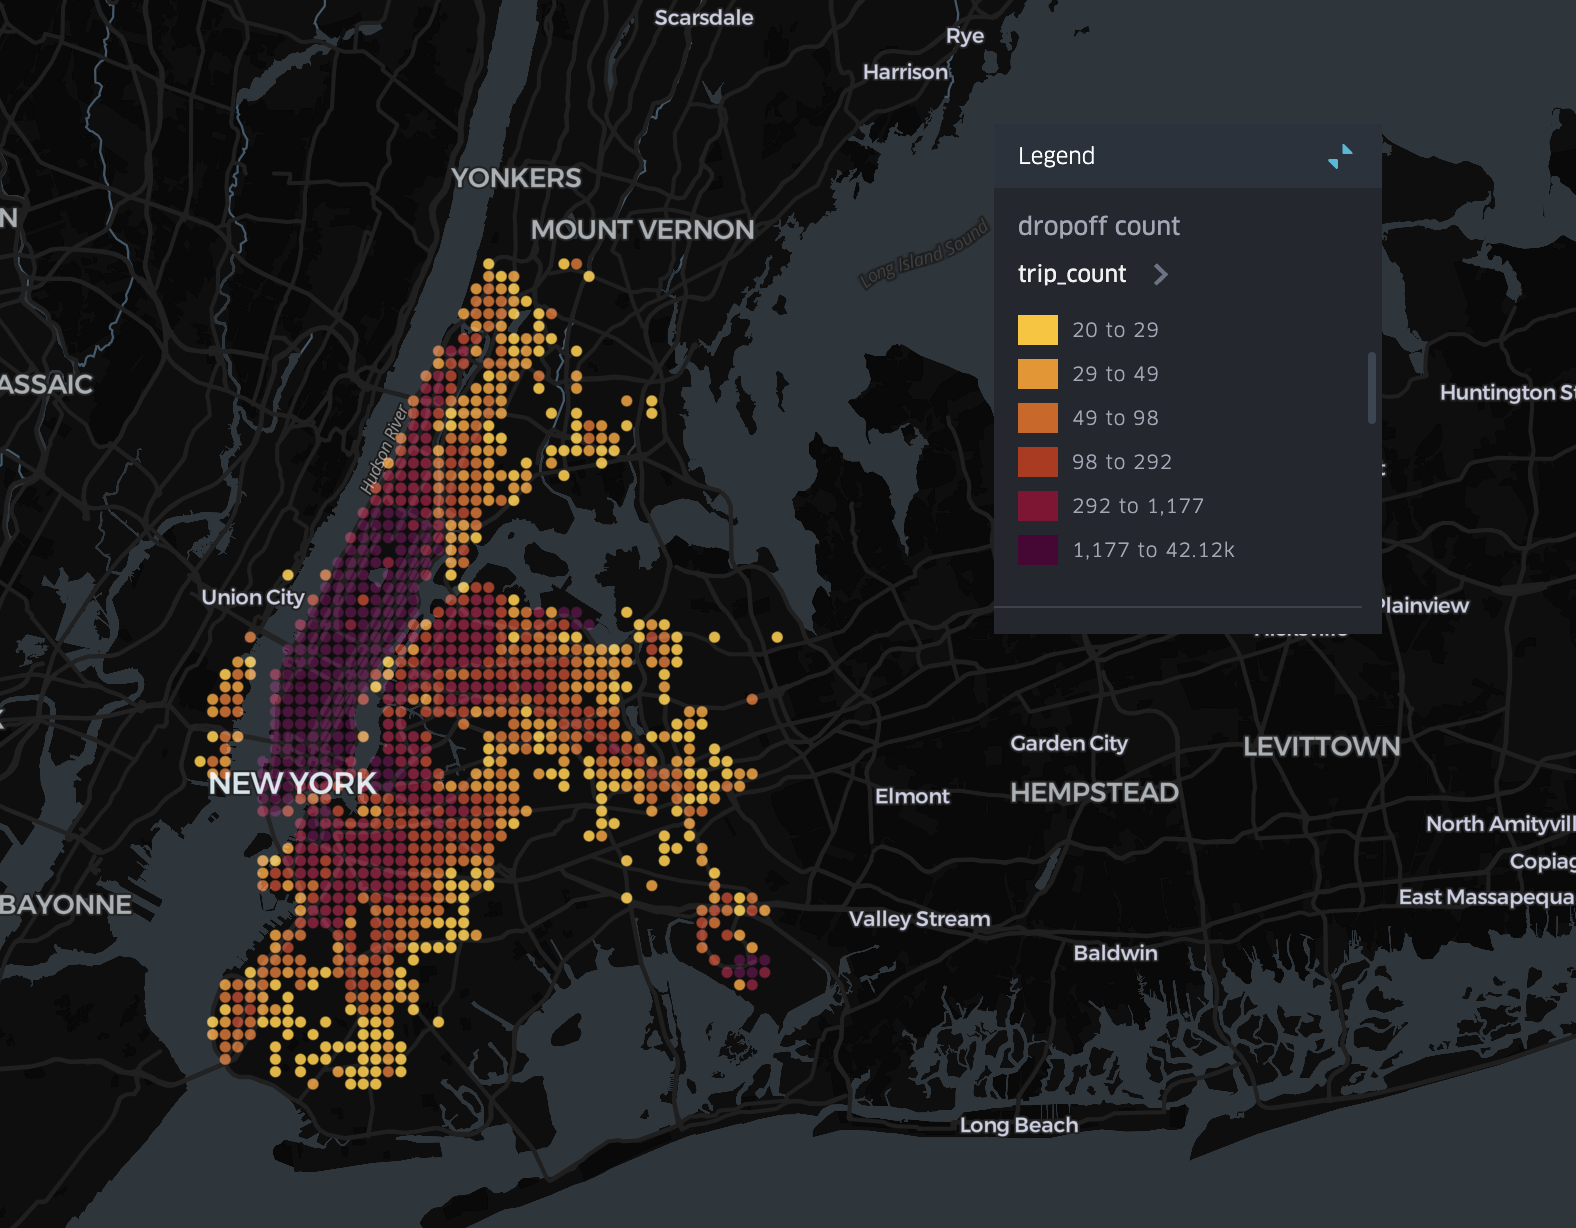

Now that we have made an initial analysis on our data we find interesting to get the top 10 highest fare per mile destinations. To do so we also filtered by drop-off destination with at least a trip count of 20.

## Figure 4: Map point chart of the top 10 hihgest fare-per-mile drop-offs.

At first we see that all these drop-offs are in the same neighborhood called Hoboken. Not in the big apple as we would have imagined.  

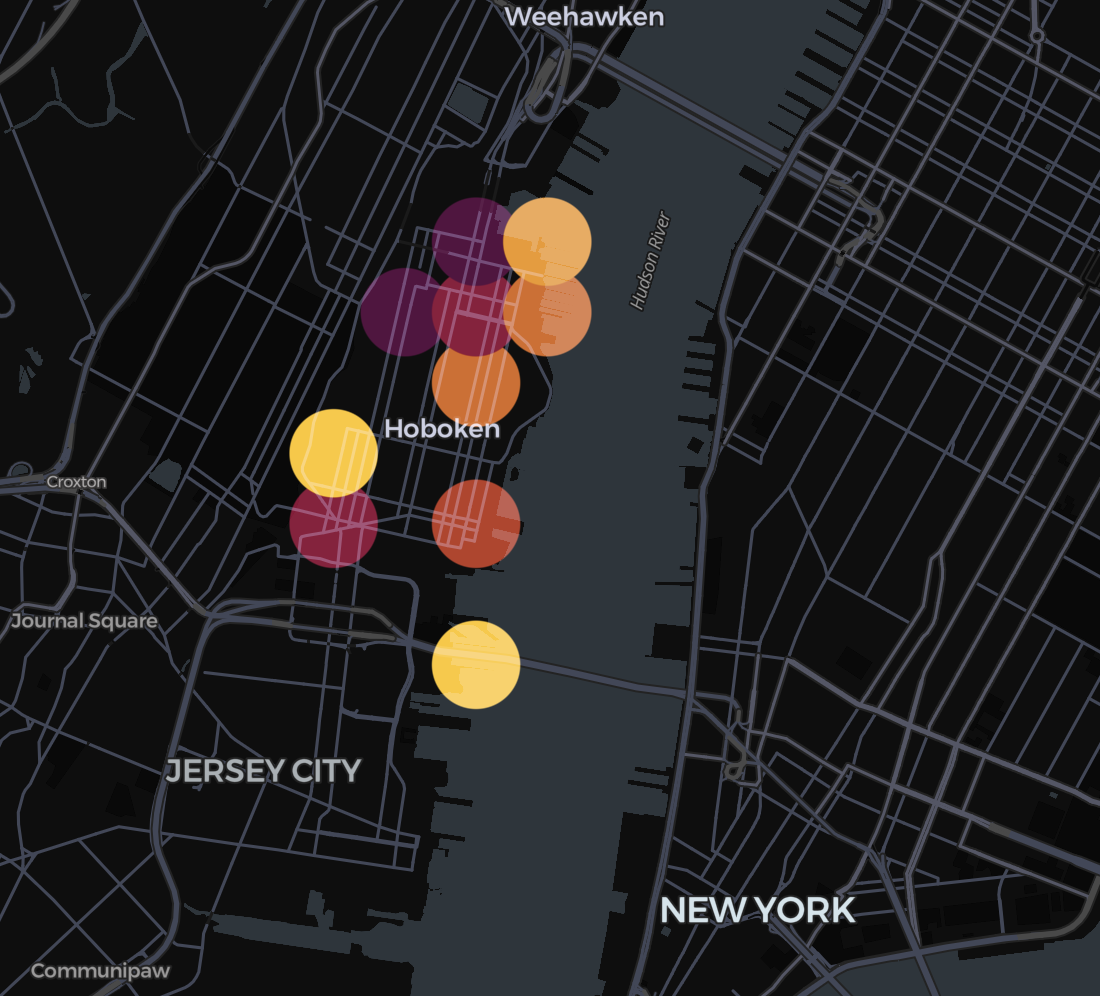

We searched for the why, and we found it:

1. **Fixed Toll Burden**
The most significant factor: Passengers pay the round-trip toll for the driver to return to NYC (since tolls are only collected entering New York). This large, fixed cost is added to the metered fare regardless of the trip's short distance.

PANYNJ bridge/tunnel tolls for a car (E-ZPass peak) can be over $$16.06 entering NYC (as of July 2025). The passenger pays this x2 for the round-trip charge, resulting in over $32 dollars in fixed toll costs for a trip that is only 2-4 miles long.

-----------------------

2. **Time-Based Charges**
NYC's taxi meter uses a combined time/distance rate. The trip often involves heavy, slow-moving traffic in the tunnels, causing the meter to charge the high waiting-time rate instead of the lower distance rate.

The NYC rate is approximately $$0.70 per 1/5 mile OR $0.70 per 60 seconds when traveling below 12 mph. A slow, 30-minute trip across 3 miles will accrue a high fare primarily from the time-based charge, inflating the overall Fare/Mile metric.



### Origin analysis

One final visualization and data that we thought would be helpful to understand better our results was to get the most frequent origin of those top 10 drop-off destinations.

## Figure 5: Arc map chart of the drop-off most frequent pickups.

With this visualization we can clearly see where are the most frequent pickup spots.

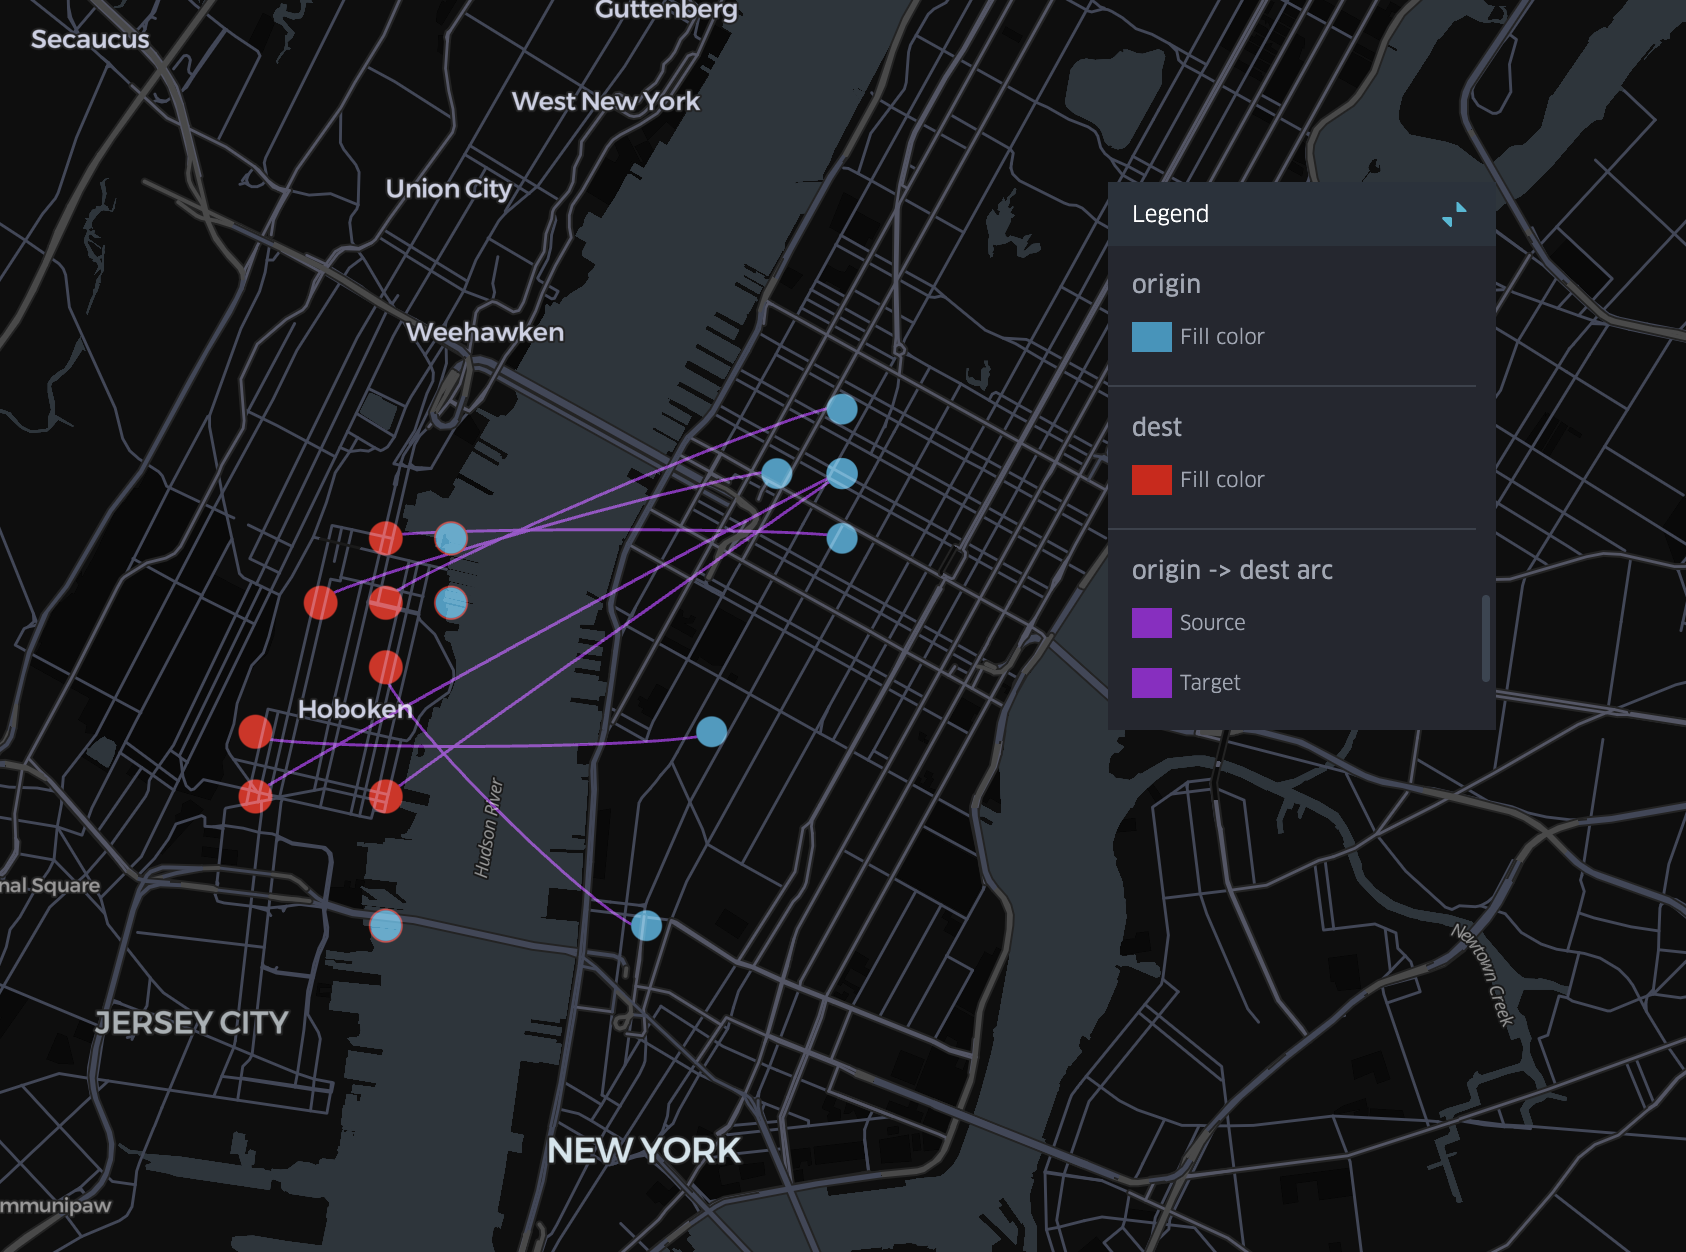

## Figure 6: Arc map chart of the drop-off pickup points.

With this visualization we can see all the points where the top 10 drop-off points came from. From outside of the big apple we see 2 clearly differentation origin spots which are the two airports (La Guardia airport and John F. Kennedy International Airport.

(In red we see the top 10 dropoff points, and the color of the arc is the avg-time of the trip)

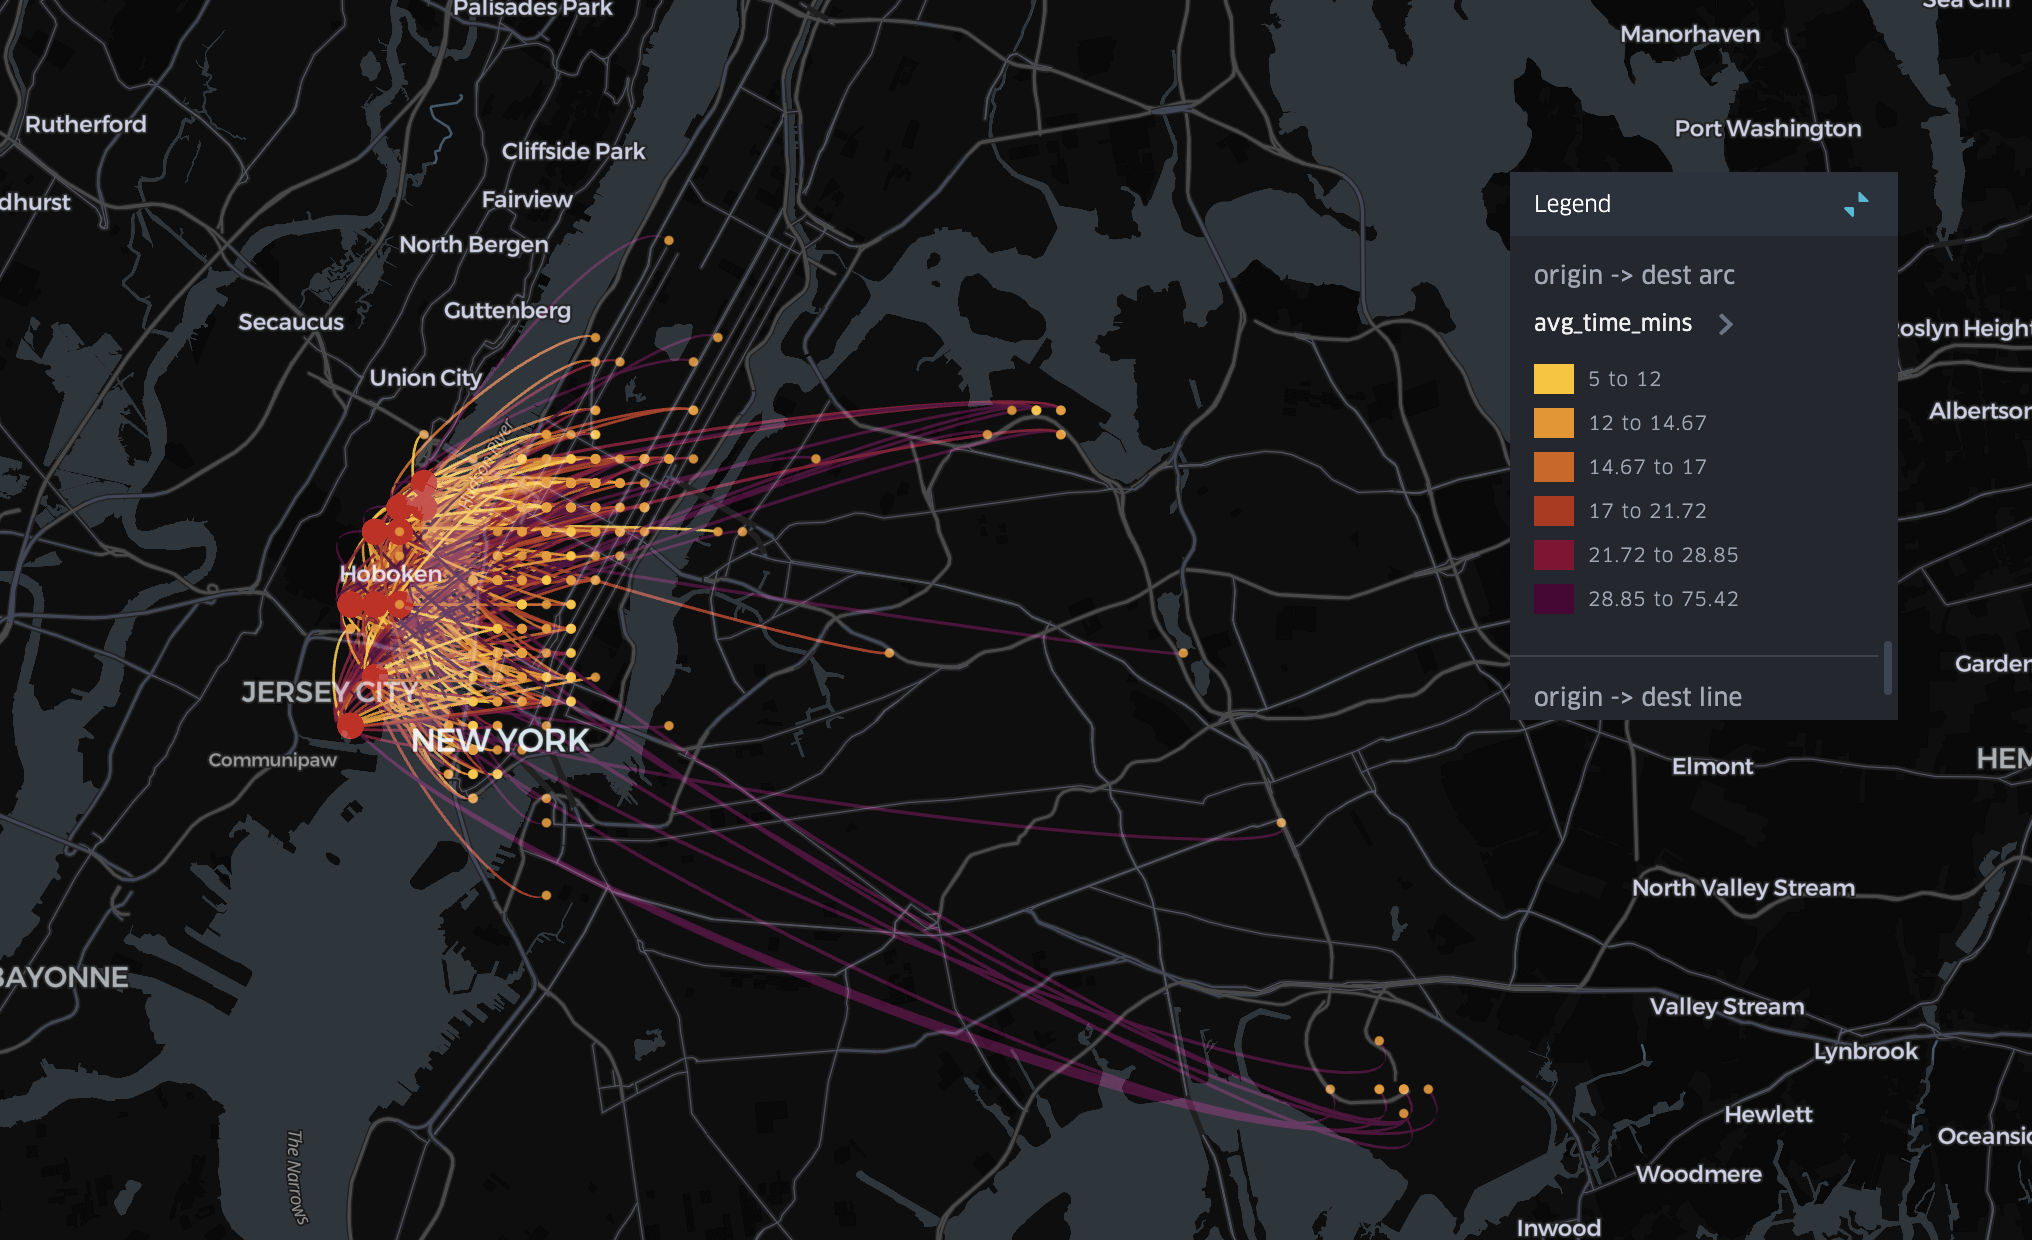

## SOURCES

1. Toll rates for all Port Authority bridges & tunnels.- Port authority NY NJ. Available at:
[Toll rates article link](https://www.panynj.gov/bridges-tunnels/en/tolls.html) (Accessed: 06 December)

2. How Taxi Meters Work - How stuff works. Available at:  [How taxi meters work link](https://auto.howstuffworks.com/taxi-meter.htm)(Accessed: 06 December)

## 1.2 Anomaly and Behavior Checks

Create driver_features

In [ ]:
#@title Download 1% sample
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

In [ ]:
from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *

spark = SparkSession.builder.master('local[*]') \
            .appName('taxis').getOrCreate()

schema = StructType([
    StructField("medallion", StringType(), True),
    StructField("hack_license", StringType(), True),
    StructField("pickup_datetime", TimestampType(), True),
    StructField("dropoff_datetime", TimestampType(), True),
    StructField("trip_time_in_secs", IntegerType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("payment_type", StringType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("surcharge", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("total_amount", DoubleType(), True)
])

data_typed3 = spark.read.csv(
    'taxi_rides_1pc.csv.gz',
    sep=',',
    header=True,
    schema=schema,
    timestampFormat='yyyy-MM-dd HH:mm:ss'
)

In [ ]:
# MIN_LON = -74.916578
# MAX_LAT = 41.47718278
# LON_DELTA = 0.005986
# LAT_DELTA = 0.004491556

# def latlon_to_grid(lat, lon):
#     return ((int)((MAX_LAT - lat)/LAT_DELTA), (int)((lon - MIN_LON)/LON_DELTA))

# def inBounds(cell):
#     return cell[0] > 0 and cell[0] < 300 and cell[1] > 0 and cell[1] < 300


# latlon_to_grid_udf = udf(lambda lat, lon: latlon_to_grid(lat, lon),
#                          StructType([StructField("row", IntegerType()), StructField("col", IntegerType())]))

# # Map pickup and dropoff
# data_filtered3 = data_typed3.withColumn("pickup_cell", latlon_to_grid_udf(col("pickup_latitude"), col("pickup_longitude"))) \
#            .withColumn("dropoff_cell", latlon_to_grid_udf(col("dropoff_latitude"), col("dropoff_longitude")))

# print(data_typed3.count())

# # Remove trips with negative distance, fare, or trip_time
# data_filtered3 = data_typed3.filter(
#     (col("trip_time_in_secs") > 0) &
#     (col("total_amount") > 0) &
#     (col("pickup_cell.row").between(0, 299)) &
#     (col("pickup_cell.col").between(0, 299)) &
#     (col("dropoff_cell.row").between(0, 299)) &
#     (col("dropoff_cell.col").between(0, 299))
# )

# print(data_filtered3.count())

# Approximate boundaries for 300x300 NYC grid area
MIN_LON = -74.05 ###################################################To discuss: In the instructions -74.916578 also not using the In Bounds check and latlon_to_grid definition
MAX_LON = -73.75
MIN_LAT = 40.6 ###########################################################41.47718278
MAX_LAT = 40.9

LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

initial_count3 = data_typed3.count()

print(initial_count3)

data_filtered3 = data_typed3.filter(
    (col("pickup_longitude").between(MIN_LON, MAX_LON)) &
    (col("pickup_latitude").between(MIN_LAT, MAX_LAT)) &
    (col("dropoff_longitude").between(MIN_LON, MAX_LON)) &
    (col("dropoff_latitude").between(MIN_LAT, MAX_LAT)) &
    (col("trip_time_in_secs") > 0) &
    (col("total_amount") > 0)
)

print(data_filtered3.count())


1735010
1691438


Create columns: avg-speed, fare-per-mile, tip-pct

Filter for:
"avg_speed_mph" <= 155 /
"tip_amount" <= 50 /
"tip_pct" <= 3 /
1 <= "tip_amount" <= 20

To get fare per mile, we computed:
fare_per_mile = fare_amount / trip_distance

We did a calculation on example trips, based on numbers from NYC Taxi & Limousine Comission, 2025, and created two different scenarios:


**A: Expensive but feasible Manhattan trip**
Example: 0.2 mile trip
3.00 (initial charge) + 0.70x1 (Distance charge) + 0.5 (MTA State surcharge) + 1 (Improvement surcharge) + 2.5 (Yellow taxi) =  $7.70 (7.70 for o.2 miles, which means 1 mile = **38.5** dollars per mile)

**B: Unlikely case with Rush hour, night, congestion, and tolls**
3.00 (initial charge) + 0.70x1 (Distance charge) + 0.5 (MTA State surcharge) + 1 (Improvement surcharge) + 2.5 (Yellow taxi) + 0.75 (Congestion Pricing Toll) + 2.50 (Rush-hour surcharge) + 1 (Overnight) + 0.75 (Congestion Pricing Toll ) = 11.95 (i mile = **59.75** dollars/mile)

However, prices have most likely increased since 2013.


In [ ]:
from pyspark.sql.functions import col

# Create avarage speed column
data_filtered3 = data_filtered3.withColumn(
    "avg_speed_mph",
    col("trip_distance") / (col("trip_time_in_secs") / 3600.0)
)

# Create fare_per_mile column
data_filtered3 = data_filtered3.withColumn(
    "fare_per_mile",
    col("fare_amount") / col("trip_distance")
)

data_filtered3 = data_filtered3.withColumn(
    "tip_pct",
    when(col("fare_amount") > 0, col("tip_amount") / col("fare_amount"))
    .otherwise(lit(0.0))
)

# print counts
fast_trips_count = data_filtered3.filter(col("avg_speed_mph") > 155).count()
print("Number of trips over 155 mph:", fast_trips_count)

high_fpm_count = data_filtered3.filter(col("fare_per_mile") > 60).count()
print("Trips with fare_per_mile > 60 USD:", high_fpm_count)
low_fpm_count  = data_filtered3.filter(col("fare_per_mile") < 1).count()
print("Trips with fare_per_mile < 1 USD:",  low_fpm_count)

tips_300_count = data_filtered3.filter(col("tip_pct") >= 3).count()
print("Trips with tip >= 300% of fare:", tips_300_count)

tips_50USD = data_filtered3.filter(col("tip_amount") > 50).count()
print("Tip amount > 50 USD:", tips_50USD)


data_filtered3 = data_filtered3.filter(
    (col("avg_speed_mph") <= 155) &
    (col("tip_amount") <= 50) &
    (col("tip_pct") <= 3) &
    (
        col("fare_per_mile").isNull() |
        (
            (col("fare_per_mile") >= 1) &
            (col("fare_per_mile") <= 60)
        )
    )
)
print("Remaining rows after cleaning:", data_filtered3.count())

Number of trips over 155 mph: 793
Trips with fare_per_mile > 60 USD: 3412
Trips with fare_per_mile < 1 USD: 1204
Trips with tip >= 300% of fare: 150
Tip amount > 50 USD: 59
Remaining rows after cleaning: 1686225


In [ ]:
from pyspark.sql.functions import avg, sum as spark_sum

driver_features = data_filtered3.groupBy("hack_license").agg(
    count("*").alias("num_trips"),
    avg("avg_speed_mph").alias("avg_speed_mph"),
    avg("fare_per_mile").alias("avg_fare_per_mile"),
    avg("tip_amount").alias("avg_tip_usd"),
    avg("tip_pct").alias("avg_tip_pct"),
    spark_sum(when(col("trip_distance") == 0, 1).otherwise(0)).alias("zero_distance_trips")
)

driver_features = driver_features.withColumn(
    "zero_distance_ratio",
    round(col("zero_distance_trips")/col("num_trips"),2))

**We computed global means and stddevs and add into driver_features**

**Reasoning of Zero distance trips:**
Zero distance trips under 20% could be system issue, hence we only flag for drivers with more than an avarage of 20% to be anoumolous. For example, a driver with higher than 80% of the trips being zero distance (several cases exist), that flags for fraud if fare is higher than normal.

**Reasoning for tip limit:**
The United States has a tipping culture, and for taxis, it is typically around 15–20% (Calder, 2023). Therefore, a driver with a low average tip is suspicious, and while it might indicate failures in the meter/tip recording subsystem, it might also be due to abnormal behaviour, unsafe driving or none reported tips. We chose to flag avarage tip lower than 2%.

In [ ]:
from pyspark.sql.functions import lit, abs as spark_abs, stddev, avg, col

stats = driver_features.select(
    avg("avg_fare_per_mile").alias("mean_fpm"),
    stddev("avg_fare_per_mile").alias("std_fpm"),
    avg("avg_speed_mph").alias("mean_speed"),
    stddev("avg_speed_mph").alias("std_speed"),
    avg("avg_tip_pct").alias("mean_tip_pct"),
    stddev("avg_tip_pct").alias("std_tip_pct"),
    avg("zero_distance_ratio").alias("mean_zero_dist"),
  stddev("zero_distance_ratio").alias("std_zero_dist")
).first()

z_threshold = 3.0

# Add z-scores
driver_features = driver_features \
    .withColumn(
        "fare_z",
        (col("avg_fare_per_mile") - lit(stats.mean_fpm)) / lit(stats.std_fpm)
    ).withColumn(
        "speed_z",
        (col("avg_speed_mph") - lit(stats.mean_speed)) / lit(stats.std_speed)
    ).withColumn(
        "tip_pct_z",
        (col("avg_tip_pct") - lit(stats.mean_tip_pct)) / lit(stats.std_tip_pct)
    ).withColumn(
        "zero_dist_z",
        (col("zero_distance_ratio") - lit(stats.mean_zero_dist)) / lit(stats.std_zero_dist)
    )

driver_features = driver_features \
    .withColumn("speed_flag", spark_abs(col("speed_z")) > z_threshold) \
    .withColumn("fare_flag", spark_abs(col("fare_z")) > z_threshold) \
    .withColumn("zero_dist_flag", col("zero_distance_ratio") >= 0.2) \
    .withColumn("low_tip_flag", col("avg_tip_pct") <= 0.02)

# Any kind of anomaly
from pyspark.sql.functions import coalesce

driver_features = driver_features.withColumn(
    "any_flag",
    coalesce(col("speed_flag"), lit(False)) |
    coalesce(col("fare_flag"), lit(False)) |
    coalesce(col("zero_dist_flag"), lit(False)) |
    coalesce(col("low_tip_flag"), lit(False))
)

**Filter drivers that has atleast 20 trips and that are flagged and print table**

Reasoning:
We then focused only on drivers with total trips ≥ 20 to avoid unstable statistics for drivers with very few rides.


In [ ]:
from pyspark.sql.functions import col

# Only drivers with at least 20 trips
driver_stats_ge5 = driver_features.filter(col("num_trips") >= 20)

print(driver_features.filter(col("zero_distance_ratio") >= 0.2))

# Count how many drivers are flagged
print("Number of drivers with (total_trips >= 20):", driver_stats_ge5.count())

# Drivers with any anomaly flag
anomalous_drivers_ge5 = driver_stats_ge5.filter(col("any_flag"))

print("Number of anomalous drivers (total_trips >= 20):", anomalous_drivers_ge5.count())

flagged_drivers = driver_features.filter(
    (col("num_trips") >= 20) &
    (col("any_flag") == True)
)

flagged_drivers.show(20, truncate=False)
print("Total flagged drivers (>=20trips):", flagged_drivers.count())

pdf = driver_features.toPandas()

DataFrame[hack_license: string, num_trips: bigint, avg_speed_mph: double, avg_fare_per_mile: double, avg_tip_usd: double, avg_tip_pct: double, zero_distance_trips: bigint, zero_distance_ratio: double, fare_z: double, speed_z: double, tip_pct_z: double, zero_dist_z: double, speed_flag: boolean, fare_flag: boolean, zero_dist_flag: boolean, low_tip_flag: boolean, any_flag: boolean]
Number of drivers with (total_trips >= 20): 31369
Number of anomalous drivers (total_trips >= 20): 138
+--------------------------------+---------+------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+---------------------+--------------------+----------+---------+--------------+------------+--------+
|hack_license                    |num_trips|avg_speed_mph     |avg_fare_per_mile |avg_tip_usd       |avg_tip_pct        |zero_distance_trips|zero_distance_ratio|fare_z             |speed_z            |tip_pct_z  

Build driver_ranked to rank drivers by anomaly scores and print the drivers with 20th highest anomoly scores.


Analysis of the 3 first drivers: (MIGHT NEED TO CHANGE; IS FOR 20 USD PER MILE)
------------------------------------
**Driver 1:** Shows  suspicious and fraudulent behaviour:

*   93% of trips report zero distance, which is very high.

*   Average speed of 2.68 mph suggests almost no movement was recorded.

*   Very high fare per mile (13.33).

*   0% tipping — passengers likely reacted to abnormal or frustrating trip experience.

**Intepretation**: Could have removed taxometer and charged costumers very highm and therefore got no tip or did not report the tip.


**Driver 2:** Does not show fraudlent behaviour, but strong diviation in speed

*   0% of trips report zero distance, which is good.

*   Average speed of 41 mph suggests very high speed for NYC.

*   Avarage fare per mile (2.65)

*   8% tipping — which is below conventional tipping standards, but not flagged.

**Intepretation**: Driver is flagged due to high speed while the other numbers are fine. Could indicate unsafe driving, but since tip is not flagged, could still also be GPS error or that the driver takes mostly highway trips.  

**Driver 3:** Shows  suspicious and fraudulent behaviour:

*   86% of trips report zero distance, which is very high.

*   very low speed of 2.39 mph suggests almost no movement was recorded.

*   very high fare per mile (9.37).

*   4.4% tipping — which is below conventional tipping standards.

**Intepretation**: As in the case of the first driver, driver 3 also could have removed taxometer and charged costumers very high, but in this case he probably reported the tip.



In [ ]:
from pyspark.sql.functions import col, abs as spark_abs, when

driver_ranked = driver_features \
    .filter(col("num_trips") >= 20) \
    .withColumn(
        "anomaly_score",
        # weight zero-distance anomalies highest
        when(col("zero_dist_flag"), 3).otherwise(0) +
        # speed & fare anomalies
        when(col("speed_flag"), 2).otherwise(0) +
        when(col("fare_flag"), 2).otherwise(0) +
        when(col("low_tip_flag"), 1).otherwise(0) +
        # add magnitude of z-scores to break ties
        spark_abs(col("speed_z")) +
        spark_abs(col("fare_z"))
    ) \
    .orderBy(col("anomaly_score").desc())

top10_drivers = driver_ranked.select(
    "hack_license", "num_trips", "anomaly_score",
    "zero_distance_trips", "zero_distance_ratio",
    "avg_speed_mph", "avg_fare_per_mile", "avg_tip_pct"
).limit(20)

print("Top 20 anomalous drivers with >= 20 trips:")
top10_drivers.show(truncate=False)

Top 20 anomalous drivers with >= 20 trips:
+--------------------------------+---------+------------------+-------------------+-------------------+------------------+------------------+--------------------+
|hack_license                    |num_trips|anomaly_score     |zero_distance_trips|zero_distance_ratio|avg_speed_mph     |avg_fare_per_mile |avg_tip_pct         |
+--------------------------------+---------+------------------+-------------------+-------------------+------------------+------------------+--------------------+
|5122F964BE8ECA925F73B6DBD3E16693|21       |25.520964532523685|0                  |0.0                |1.8341379090561833|35.495371654246235|0.11332010486092273 |
|FF4D376B97B2C47F88B93BB2F563B3D6|23       |25.08550075983099 |0                  |0.0                |2.1794593500667663|34.96342708499759 |0.11790763030592663 |
|0BE75C352825AE8C6F3279D65F74E45B|27       |25.025209134350014|0                  |0.0                |1.8724297132512997|34.67429318390001 |0

Figure 1: Top 50 Drivers by Anomaly Score presented visually - UPDATE AFTER DECIDING FARE/MILE LIMITATION
----------------------------------------------------------------------

Analysis:
We displayed 50 drivers with the highest anomaly scores.
Out of a total of 31,306 drivers with at least 20 trips, 112 were flagged as anomalous, representing only 0.36% of all drivers.

Flagging only this small percentage of drivers indicates that the anomaly system is not very sensitive.

Since thresholds were set very strictly (z-scores > 3, zero-distance ratio ≥ 0.20, and very low tip percentage), only the most extreme and consistent deviations are captured. This should reduce risk of capturing drivers that had issues with thier GPS or other forms of system issues.





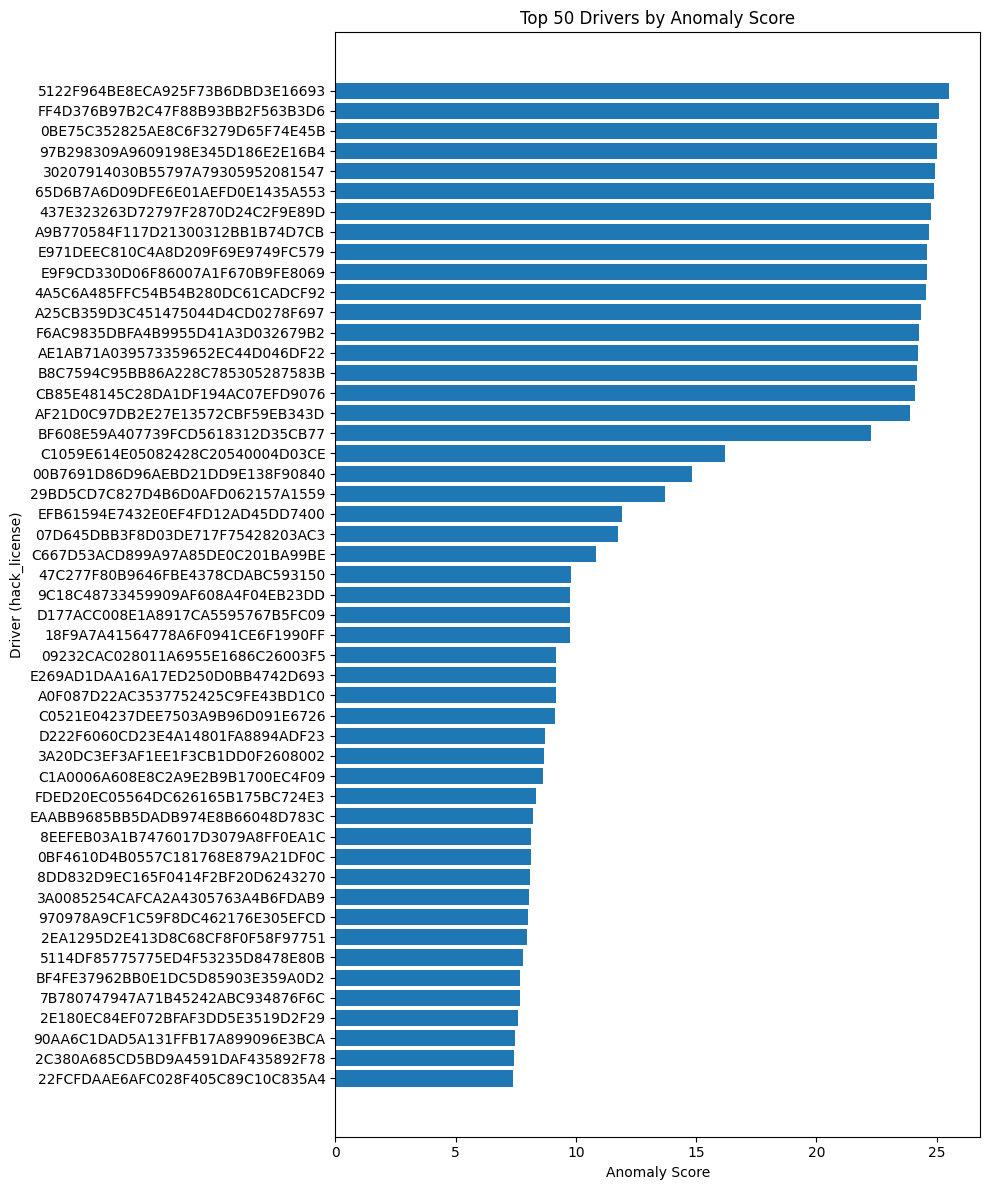

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top50 = driver_ranked.orderBy("anomaly_score", ascending=False).limit(50)
top50_pdf = top50.toPandas()

top50_pdf = top50_pdf.sort_values("anomaly_score", ascending=True)

plt.figure(figsize=(10, 12))

plt.barh(
    top50_pdf["hack_license"].astype(str),
    top50_pdf["anomaly_score"]
)

plt.xlabel("Anomaly Score")
plt.ylabel("Driver (hack_license)")
plt.title("Top 50 Drivers by Anomaly Score")
plt.tight_layout()
plt.show()

Figure 2: Heatmap of Anomaly Features (Top Flagged Drivers) WRITE AFTER DECIDING FARE/MILE LIMITATION
----------------------------------------------------------------------

Analysis:
1.  

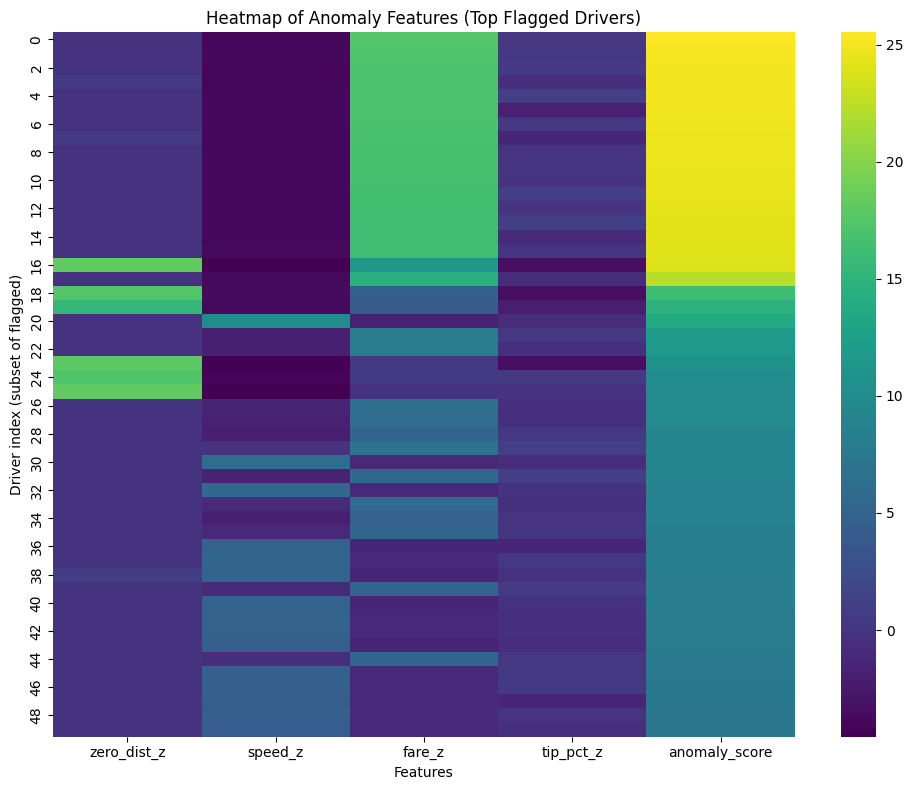

In [ ]:
# Use only flagged drivers
flagged_pdf = driver_ranked.filter("any_flag = true").toPandas()

# Choose the features to visualise
features = [
    "zero_dist_z",
    "speed_z",
    "fare_z",
    "tip_pct_z",
    "anomaly_score"
]

# Optionally limit to top N most anomalous drivers for readability
flagged_pdf = flagged_pdf.sort_values("anomaly_score", ascending=False).head(50)

heat_data = flagged_pdf[features]

plt.figure(figsize=(10, 8))
sns.heatmap(
    heat_data,
    annot=False,
    cmap="viridis",
    cbar=True
)

plt.title("Heatmap of Anomaly Features (Top Flagged Drivers)")
plt.xlabel("Features")
plt.ylabel("Driver index (subset of flagged)")
plt.tight_layout()
plt.show()


Figure 3: Parallel Coordinates: Behaviour Profiles of Flagged Drivers - WRITE AFTER DECIDING FARE/MILE LIMITATION
----------------------------------------------------------------------

Analysis:
1.

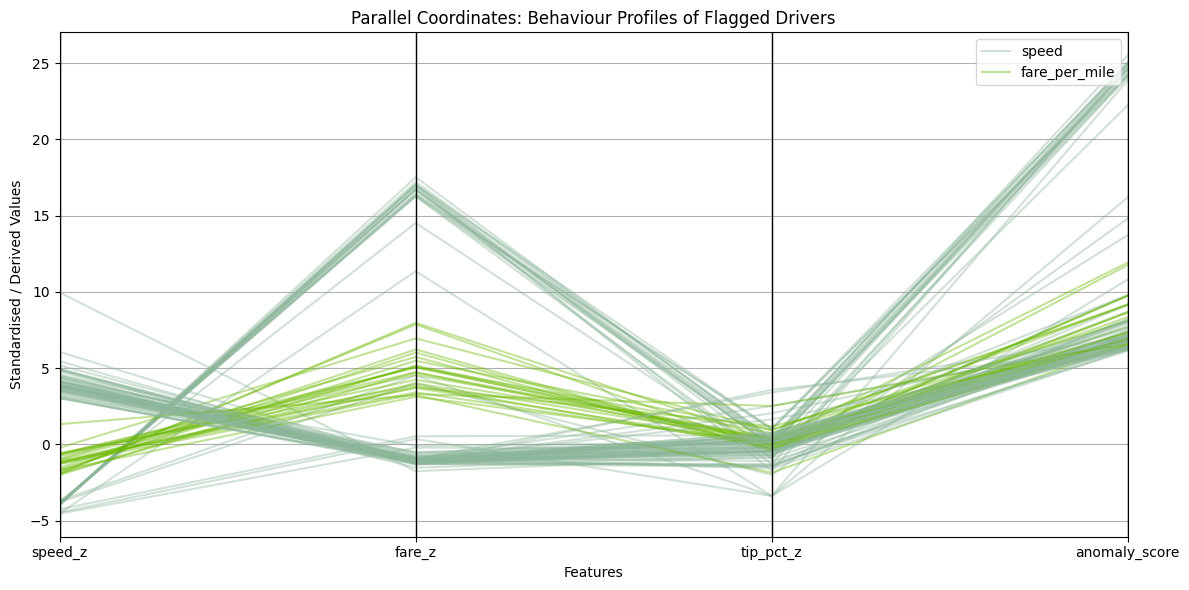

In [ ]:
from pandas.plotting import parallel_coordinates

# Start from flagged drivers only
coords_pdf = driver_ranked.filter("any_flag = true").toPandas()

# Create a categorical column to colour by dominant anomaly
def dominant_anomaly(row):
    if row.get("speed_flag"):
        return "speed"
    if row.get("fare_flag"):
        return "fare_per_mile"
    if row.get("low_tip_flag"):
        return "tip_pct"
    #if row.get("zero_tip_pattern_flag"):
        #return "zero_tip_pattern"
    return "other"

coords_pdf["anomaly_type"] = coords_pdf.apply(dominant_anomaly, axis=1).astype(str)

# Optionally restrict to top 100 by anomaly score for legibility
coords_pdf = coords_pdf.sort_values("anomaly_score", ascending=False).head(100)

# Select features to visualise (z-scores work well)
coord_features = ["speed_z", "fare_z", "tip_pct_z", "anomaly_score"]

# Build a DataFrame for parallel coordinates
pc_df = coords_pdf[coord_features + ["anomaly_type"]].copy()

plt.figure(figsize=(12, 6))
parallel_coordinates(
    pc_df,
    "anomaly_type",
    alpha=0.4
)

plt.title("Parallel Coordinates: Behaviour Profiles of Flagged Drivers")
plt.xlabel("Features")
plt.ylabel("Standardised / Derived Values")
plt.tight_layout()
plt.show()

Figure 4: Correlation Between Driver-Level Metrics
----------------------------------------------------------------------

Analysis:
1.

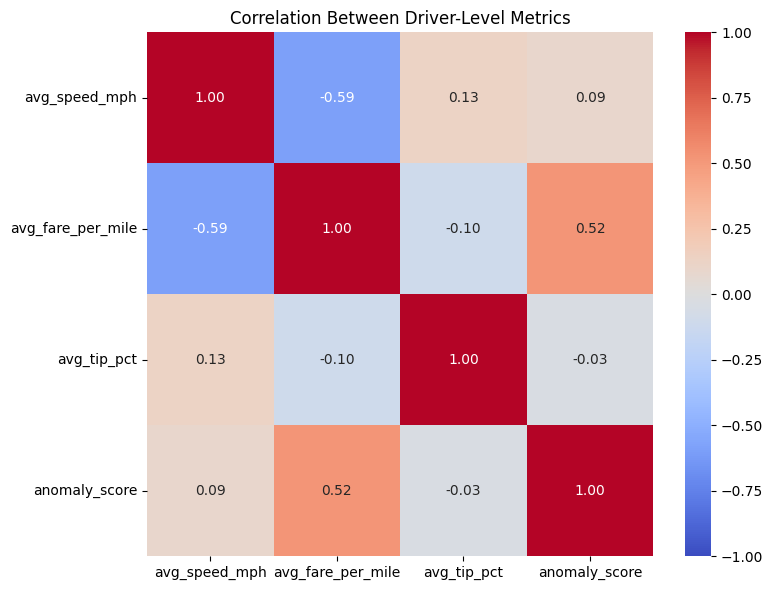

In [ ]:
corr_pdf = driver_ranked.select(
    "avg_speed_mph",
    "avg_fare_per_mile",
    "avg_tip_pct",
    "anomaly_score"
).toPandas()

corr_matrix = corr_pdf.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Between Driver-Level Metrics")
plt.tight_layout()
plt.show()


Sources:
----------------------------------------
1. Calder, S. (2023) What are the rules for tipping in America?, The Independent. Available at: https://www.independent.co.uk/travel/north-america/usa/tip-usa-america-restaurant-taxi-hotel-b2305903.html (Accessed: 01 December 2025).

2. NYC Taxi & Limousine Comission (2025) Taxi fare, Taxi Fare - TLC. Available at: https://www.nyc.gov/site/tlc/passengers/taxi-fare.page (Accessed: 01 December 2025).
